In [1]:
from heaict.ml.mode import GNN
from heaict.cats.surface import brute_force_surface, get_activity_selectivity
import numpy as np
import matplotlib.pyplot as plt
from heaict.ml.utility import fix_seed
from heaict.para import *
import torch
import pandas as pd
from Jworkflow.plot import gradient_graphics, energy_diagram
from Jworkflow.electronic import Lobster_PProcess
from pymatgen.electronic_structure.core import Spin

# Create data

In [2]:
modeln = GNN(**para_model)
modeln.load_state_dict(torch.load(f'model_test/Model_251007_dict.pt'))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
modeln = modeln.to(device)

In [4]:
bfs = brute_force_surface(surface_size=(150, 150), n_layers=3, para_grab_feature=para_grab_feature)
bfs.read_archetype(f'Data/Archetype_slab/n3/', zero_frac, grid_basis_in_frac, para_constr_graph={}, para_infer_site={}, para_add_feat=para_add_feat)
fix_seed(666)
bfs.create_slab_HEA({'Ni':0.08, 'Pd': 0.35, 'Cu':0.07, 'Mo': 0.35, 'Mn': 0.15})
bfs.eval_gross_energies(modeln, batch_size=7500, Ecor={})

In [5]:
bfs.get_net_energies(reaction_steps=reaction_steps)
ii = get_activity_selectivity(bfs.site_adsenergy, get_NRR_site_indices_at=-0.35)

In [6]:
cc = bfs.count_site(grid_vector=grid_basis_in_frac@slab_lattice, indices=ii)

In [6]:
cc

[([{42}, {25, 42}], 347),
 ([{42}, {42}], 193),
 ([{25, 42}, {42}], 182),
 ([{42}, {25}], 99),
 ([{25, 42}, {25, 42}], 84),
 ([{42, 46}, {42}], 78),
 ([{25, 42}, {25}], 64),
 ([{42}, {42, 46}], 22),
 ([{25, 46}, {42}], 9),
 ([{25, 28}, {25, 42}], 7),
 ([{28, 42}, {42}], 5),
 ([{25}, {42}], 4),
 ([{25}, {25}], 2),
 ([{25}, {25, 42}], 2),
 ([{29, 42}, {42}], 1),
 ([{42}, {25, 28}], 1)]

In [9]:
bfs.site_adsenergy['H'].shape

(5264,)

# Figure 6a

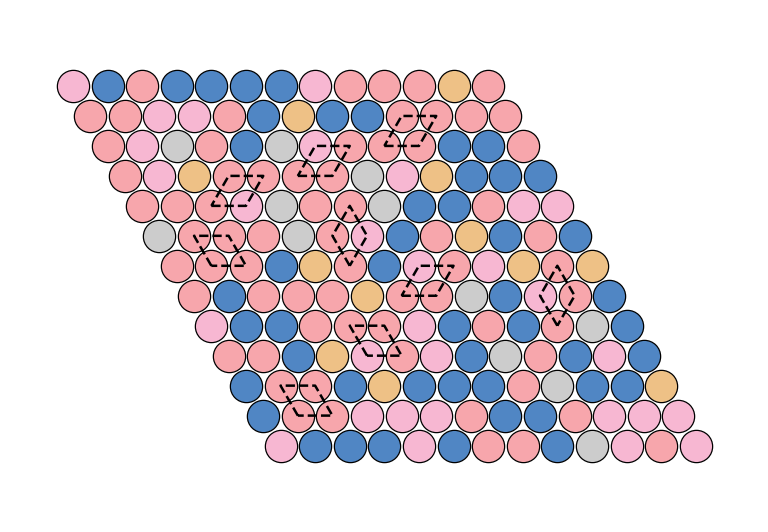

In [291]:
plt.rc('font',family='Arial')
l=6;h=4
fig=plt.figure(figsize=(l/2.54, h/2.54),dpi=300)

ax0=fig.add_axes([0,0,1,1])
ax0.set_xlim(0,1);ax0.set_ylim(0,1);ax0.set_xticks([]);ax0.set_yticks([]);ax0.axis('off')
ax0.patch.set_alpha(0.0)

ax=fig.add_axes([0.1/l, 0.1/h, 5.8/l, 3.8/h])

color_dict = {'Ni': '#CCCCCC', 'Pd': '#5086C4', 'Cu': '#EEC186', 'Mo': '#F7A6AC', 'Mn': '#F7B7D2'}
atomic_vector = grid_basis_in_frac @ slab_lattice
x_range=(37, 50)
y_range=(90, 103)

bfs.plot_surface(ax, color_dict, atomic_vector, x_range, y_range, 1, ii, True,  
                atom_edge={'linestyle': '-', 'edgecolor': 'k', 's':60, 'lw':0.3}, site_line={'linestyle': '--', 'color': 'k', 'lw': 0.6})

# fig.savefig('Figure_6_a.tif',dpi=300)

# Figure 6b

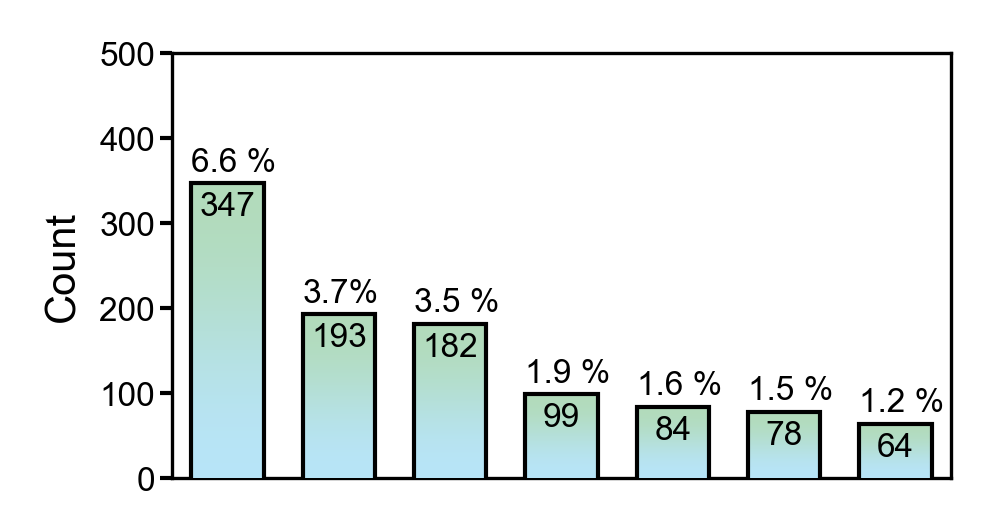

In [28]:
plt.rc('font',family='Arial')
l=8;h=4
fig=plt.figure(figsize=(l/2.54, h/2.54),dpi=300)

ax0=fig.add_axes([0,0,1,1])
ax0.set_xlim(0,1);ax0.set_ylim(0,1);ax0.set_xticks([]);ax0.set_yticks([]);ax0.axis('off')
ax0.patch.set_alpha(0.0)

ax=fig.add_axes([1.2/l, 0.2/h, 6.6/l, 3.6/h])
ax.set_zorder(2); ax.patch.set_alpha(0.0); ax.tick_params(length=3,width=1,labelsize=8,pad=1)
ax.set_xticks([]); ax.set_ylabel('Count', fontsize=10)
ax.set_ylim(0, 500); ax.set_yticks([0, 100, 200, 300, 400, 500])
ax.set_xlim(-0.5, 13.5)
percentages=['6.6 %', '3.7%', '3.5 %', '1.9 %', '1.6 %', '1.5 %', '1.2 %'] # 5264
for i, n in enumerate([347, 193, 182, 99, 84, 78, 64]):
    x=np.array([i-0.15, i-0.15, i+1.15, i+1.15]) + i
    y=[0, n, n, 0]
    gradient_graphics(ax, x=x, y=y, colormap=[(0, '#B8E5FA'), (1, '#B2DBB9')], zorder=10)
    ax.text(i+i+0.5, n-10, str(n), ha='center', va='top', fontsize=8, zorder=20)
    ax.text(i+i-0.15, n+6, percentages[i], ha='left', va='bottom', fontsize=8, zorder=20)
    
# fig.savefig('Figure_6_b.tif',dpi=300)

# Figure 6d

In [2]:
df_step = pd.read_excel(f'Data/DFT_result/Path_step.xlsx', index_col=0)

In [3]:
df_step

,N2(g),N2,NNH,NHNH,NHNH2,NNH2,N,NH,NH2,NH3,H,barrier,PDS,NH3(g)
Mo2Mn2-Pd,0,-1.162485,-1.044351,-0.781382,-0.617194,-0.890606,-1.685936,-2.030354,-1.685655,-1.401378,-0.587723,0.344699,NH->NH2,-0.6391
Mo2Mn2-Mo,0,-1.293834,-1.274370,-1.099696,-0.801336,-1.170962,-1.976085,-2.228570,-1.750358,-1.615788,-0.633642,0.478211,NH->NH2,-0.6391
Mo4-Pd,0,-1.024354,-0.903744,-0.885521,-0.540160,-0.892634,-1.849978,-1.959674,-1.546428,-1.652086,-0.504829,0.413246,NH->NH2,-0.6391
Mo3Mn-Pd,0,-1.098271,-0.907372,-0.763762,-0.434837,-0.849039,-1.756283,-1.900475,-1.577193,-1.576351,-0.492415,0.323281,NH->NH2,-0.6391


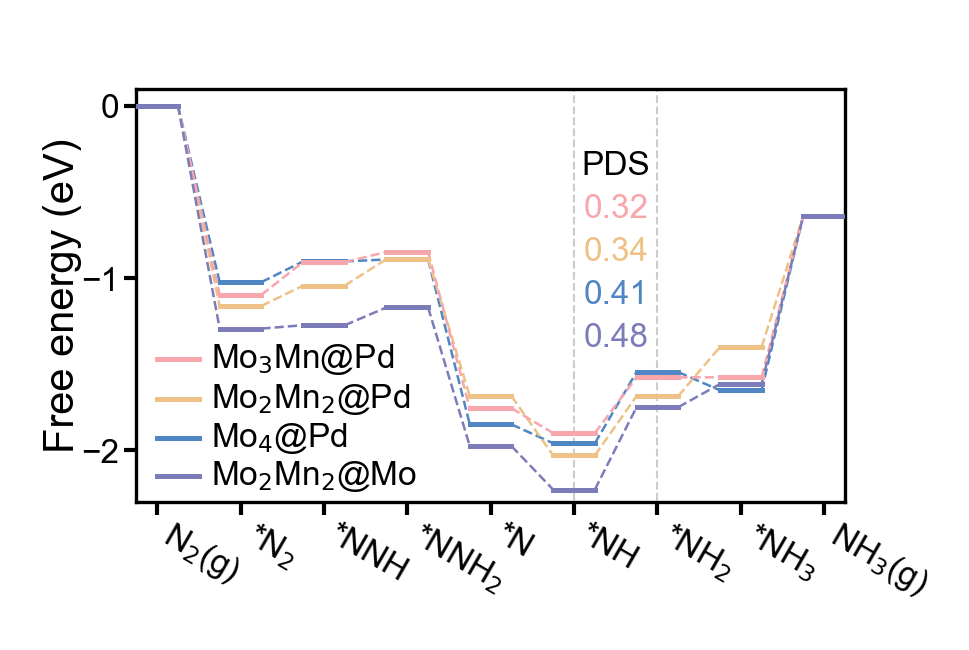

In [303]:
plt.rc('font',family='Arial')
l=7.7;h=5
fig=plt.figure(figsize=(l/2.54, h/2.54),dpi=300)

ax0=fig.add_axes([0,0,1,1])
ax0.set_xlim(0,1);ax0.set_ylim(0,1);ax0.set_xticks([]);ax0.set_yticks([]);ax0.axis('off')
ax0.patch.set_alpha(0.0)

ax=fig.add_axes([0.9/l, 1.0/h, 6/l, 3.5/h])
ax.set_zorder(2); ax.patch.set_alpha(0.0)


c = '#5086C4'
stepinfo=[[[('N2(g)', c)]],[[('N2', c)], [[(0, c)]]],[[('NNH', c)], [[(0, c)]]],
        [[('NNH2', c)], [[(0, c)]]], [[('N', c)], [[(0, c)]]], [[('NH', c)], [[(0, c)]]], 
        [[('NH2', c)], [[(0, c)]]], [[('NH3', c)], [[(0, c)]]], [[('NH3(g)', c)], [[(0, c)]]]]
energy_diagram(ax, df_step, 'Mo4-Pd', stepinfo)

c = '#EEC186'
stepinfo=[[[('N2(g)', c)]],[[('N2', c)], [[(0, c)]]],[[('NNH', c)], [[(0, c)]]],
        [[('NNH2', c)], [[(0, c)]]], [[('N', c)], [[(0, c)]]], [[('NH', c)], [[(0, c)]]], 
        [[('NH2', c)], [[(0, c)]]], [[('NH3', c)], [[(0, c)]]], [[('NH3(g)', c)], [[(0, c)]]]]
energy_diagram(ax, df_step, 'Mo2Mn2-Pd', stepinfo)

c = '#F7A6AC'
stepinfo=[[[('N2(g)', c)]],[[('N2', c)], [[(0, c)]]],[[('NNH', c)], [[(0, c)]]],
        [[('NNH2', c)], [[(0, c)]]], [[('N', c)], [[(0, c)]]], [[('NH', c)], [[(0, c)]]], 
        [[('NH2', c)], [[(0, c)]]], [[('NH3', c)], [[(0, c)]]], [[('NH3(g)', c)], [[(0, c)]]]]
energy_diagram(ax, df_step, 'Mo3Mn-Pd', stepinfo)

c = '#7C7CBA'
stepinfo=[[[('N2(g)', c)]],[[('N2', c)], [[(0, c)]]],[[('NNH', c)], [[(0, c)]]],
        [[('NNH2', c)], [[(0, c)]]], [[('N', c)], [[(0, c)]]], [[('NH', c)], [[(0, c)]]], 
        [[('NH2', c)], [[(0, c)]]], [[('NH3', c)], [[(0, c)]]], [[('NH3(g)', c)], [[(0, c)]]]]
energy_diagram(ax, df_step, 'Mo2Mn2-Mo', stepinfo, 
               # set_ylabel=('Free energy (eV)', 10),
               # set_legend=[
               #    [['Mo$_3$Mn@Pd', '#F7A6AC', 1.2, '-'],
               #    ['Mo$_2$Mn$_2$@Pd', '#EEC186', 1.2, '-'],
               #    ['Mo$_4$@Pd', '#5086C4', 1.2, '-'],
               #    ['Mo$_2$Mn$_2$@Mo', '#7C7CBA', 1.2, '-']],
               #    7, 3],
               show_space_line=False,
               xticks=['N$_2$(g)', '*N$_2$', '*NNH', '*NNH$_2$', '*N', '*NH', '*NH$_2$', '*NH$_3$', 'NH$_3$(g)']
              )
ax.set_ylim(-2.3, 0.1); ax.set_yticks([-2, -1, 0])
ax.tick_params(length=3,width=1,labelsize=8,pad=1)
ax.plot([12.5, 12.5], [-3, 1], lw=0.5, c='#CCCCCC', ls='--')
ax.plot([10.5, 10.5], [-3, 1], lw=0.5, c='#CCCCCC', ls='--')
ax.text(11.5, -0.35, 'PDS', fontsize=8, ha='center', va='center')
ax.text(11.5, -0.6, '0.32', fontsize=8, ha='center', va='center',c='#F7A6AC')
ax.text(11.5, -0.85, '0.34', fontsize=8, ha='center', va='center', c='#EEC186')
ax.text(11.5, -1.1, '0.41', fontsize=8, ha='center', va='center', c='#5086C4')
ax.text(11.5, -1.35, '0.48', fontsize=8, ha='center', va='center', c='#7C7CBA')
ax.set_ylabel('Free energy (eV)', fontsize=10, labelpad=0)
ax.plot([0.5, 1.5], [-1.47, -1.47], c='#F7A6AC', lw=1.2); ax.text(1.8, -1.47, 'Mo$_3$Mn@Pd', fontsize=8, ha='left', va='center')
ax.plot([0.5, 1.5], [-1.7, -1.7], c='#EEC186', lw=1.2); ax.text(1.8, -1.7, 'Mo$_2$Mn$_2$@Pd', fontsize=8, ha='left', va='center')
ax.plot([0.5, 1.5], [-1.93, -1.93], c='#5086C4', lw=1.2); ax.text(1.8, -1.93, 'Mo$_4$@Pd', fontsize=8, ha='left', va='center')
ax.plot([0.5, 1.5], [-2.15, -2.15], c='#7C7CBA', lw=1.2); ax.text(1.8, -2.15, 'Mo$_2$Mn$_2$@Mo', fontsize=8, ha='left', va='center')

# fig.savefig('Figure_6_d.tif',dpi=300)

# Figure 6e

In [12]:
df_step.index

Index(['Mo2Mn2-Pd', 'Mo2Mn2-Mo', 'Mo4-Pd', 'Mo3Mn-Pd'], dtype='object')

Text(-0.45, -0.5, 'HER')

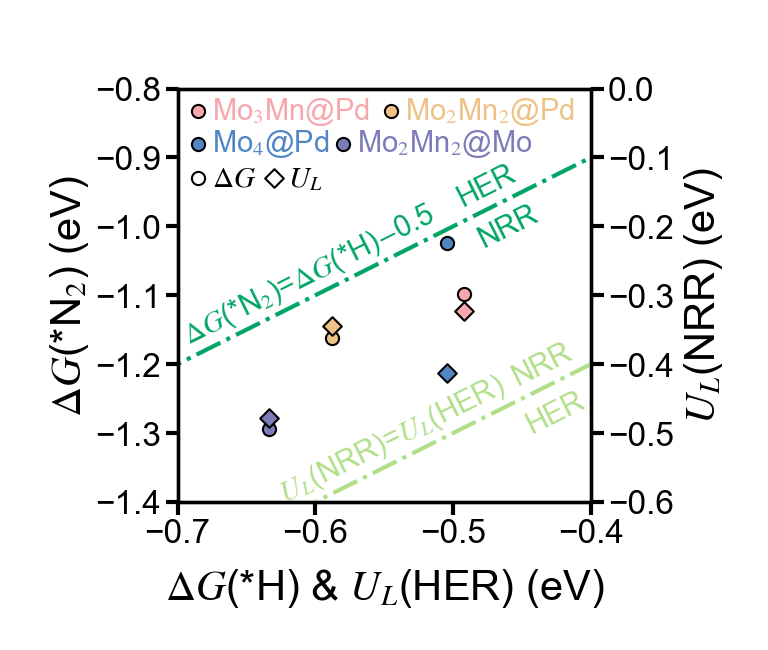

In [16]:
plt.rc('font',family='Arial')
plt.rcParams['mathtext.fontset'] = 'stix'
l=6;h=5
fig=plt.figure(figsize=(l/2.54, h/2.54),dpi=300)

ax0=fig.add_axes([0,0,1,1])
ax0.set_xlim(0,1);ax0.set_ylim(0,1);ax0.set_xticks([]);ax0.set_yticks([]);ax0.axis('off')
ax0.patch.set_alpha(0.0)

systems = ['Mo3Mn-Pd', 'Mo2Mn2-Pd', 'Mo4-Pd', 'Mo2Mn2-Mo']
colors = ['#F7A6AC', '#EEC186', '#5086C4', '#7C7CBA']

ax=fig.add_axes([1.25/l, 1.0/h, 3.5/l, 3.5/h])
ax.tick_params(length=3,width=1,labelsize=8,pad=1)
# ax.set_facecolor('#CCCCCC');ax.patch.set_alpha(0.3)

for i, sys in enumerate(systems):
    ax.scatter(df_step.at[sys, 'H'], df_step.at[sys, 'N2'], c=colors[i], s=10, edgecolors='k', lw=0.5)

ax.plot([-1, 1], [-1.5, 0.5], c='#00A664', lw=1, ls='-.')
ax.set_xlim(-0.7, -0.4); ax.set_ylim(-1.4, -0.8)
ax.set_ylabel('$\Delta G$(*N$_2$) (eV)', fontsize=10, labelpad=1)
ax.set_xlabel('$\Delta G$(*H) & $U_L$(HER) (eV)', fontsize=10)

ax2 = ax.twinx()
ax2.tick_params(length=3,width=1,labelsize=8,pad=1)
for i, sys in enumerate(systems):
    ax2.scatter(df_step.at[sys, 'H'], -1 * df_step.at[sys, 'barrier'], c=colors[i], s=10, edgecolors='k', lw=0.5, marker='D')
ax2.set_ylim(-0.6, 0.0)
ax2.plot([-1, 1], [-1, 1], lw=1, ls='-.', c='#B2DF8A')
ax2.set_ylabel('$U_L$(NRR) (eV)', fontsize=10, labelpad=2)

ax2.scatter(-0.685, -0.033, c=colors[0], s=10, edgecolors='k', lw=0.5); ax2.text(-0.675, -0.033, 'Mo$_3$Mn@Pd', c=colors[0], fontsize=7, ha='left', va='center')
ax2.scatter(-0.545, -0.033, c=colors[1], s=10, edgecolors='k', lw=0.5); ax2.text(-0.535, -0.033, 'Mo$_2$Mn$_2$@Pd', c=colors[1], fontsize=7, ha='left', va='center')
ax2.scatter(-0.685, -0.08, c=colors[2], s=10, edgecolors='k', lw=0.5); ax2.text(-0.675, -0.08, 'Mo$_4$@Pd', c=colors[2], fontsize=7, ha='left', va='center')
ax2.scatter(-0.58, -0.08, c=colors[3], s=10, edgecolors='k', lw=0.5); ax2.text(-0.57, -0.08, 'Mo$_2$Mn$_2$@Mo', c=colors[3], fontsize=7, ha='left', va='center')
ax2.scatter(-0.685, -0.13, c='w', s=10, edgecolors='k', lw=0.5); ax2.text(-0.675, -0.13, '$\Delta G$', fontsize=7, ha='left', va='center')
ax2.scatter(-0.63, -0.13, c='w', s=10, edgecolors='k', lw=0.5, marker='D'); ax2.text(-0.62, -0.13, '$U_L$', fontsize=7, ha='left', va='center')
ax2.text(-0.7, -0.37, '$\Delta G$(*N$_2$)=$\Delta G$(*H)$-$0.5', c='#00A664', fontsize=7, rotation=26.6)
ax2.text(-0.5, -0.17, 'HER', c='#00A664', fontsize=7, rotation=26.6)
ax2.text(-0.485, -0.23, 'NRR', c='#00A664', fontsize=7, rotation=26.6)
ax2.text(-0.63, -0.6, '$U_L$(NRR)=$U_L$(HER)', c='#B2DF8A', fontsize=7, rotation=26.6)
ax2.text(-0.46, -0.43, 'NRR', c='#B2DF8A', fontsize=7, rotation=26.6)
ax2.text(-0.45, -0.5, 'HER', c='#B2DF8A', fontsize=7, rotation=26.6)

# fig.savefig('Figure_6_e.tif',dpi=300)

# Figure 6f-...

In [25]:
LP_N2Pd=Lobster_PProcess()
LP_N2Pd.read_car(f'Data/DFT_result/Electronic/91_N2h_-60_6b/COHPCAR.lobster', f'Data/DFT_result/Final_structure/91_N2h_-60_6b.vasp')
LP_N2Pd.read_car(f'Data/DFT_result/Electronic/91_N2h_-60_6b/DOSCAR.lobster', f'Data/DFT_result/Final_structure/91_N2h_-60_6b.vasp', 'dos')
LP_N2Mo=Lobster_PProcess()
LP_N2Mo.read_car(f'Data/DFT_result/Electronic/91f_N2h_-60_6b/COHPCAR.lobster', f'Data/DFT_result/Final_structure/91f_N2h_-60_6b.vasp')
LP_N2Mo.read_car(f'Data/DFT_result/Electronic/91f_N2h_-60_6b/DOSCAR.lobster', f'Data/DFT_result/Final_structure/91f_N2h_-60_6b.vasp', 'dos')
LP_NH=Lobster_PProcess()
LP_NH.read_car(f'Data/DFT_result/Electronic/Mo3Mn_NH_0_10h/COHPCAR.lobster', f'Data/DFT_result/Final_structure/Mo3Mn_NH_0_10h.vasp')
LP_NH.read_car(f'Data/DFT_result/Electronic/Mo3Mn_NH_0_10h/DOSCAR.lobster', f'Data/DFT_result/Final_structure/Mo3Mn_NH_0_10h.vasp', 'dos')

Text(0.72, 0.93, 'Spin down')

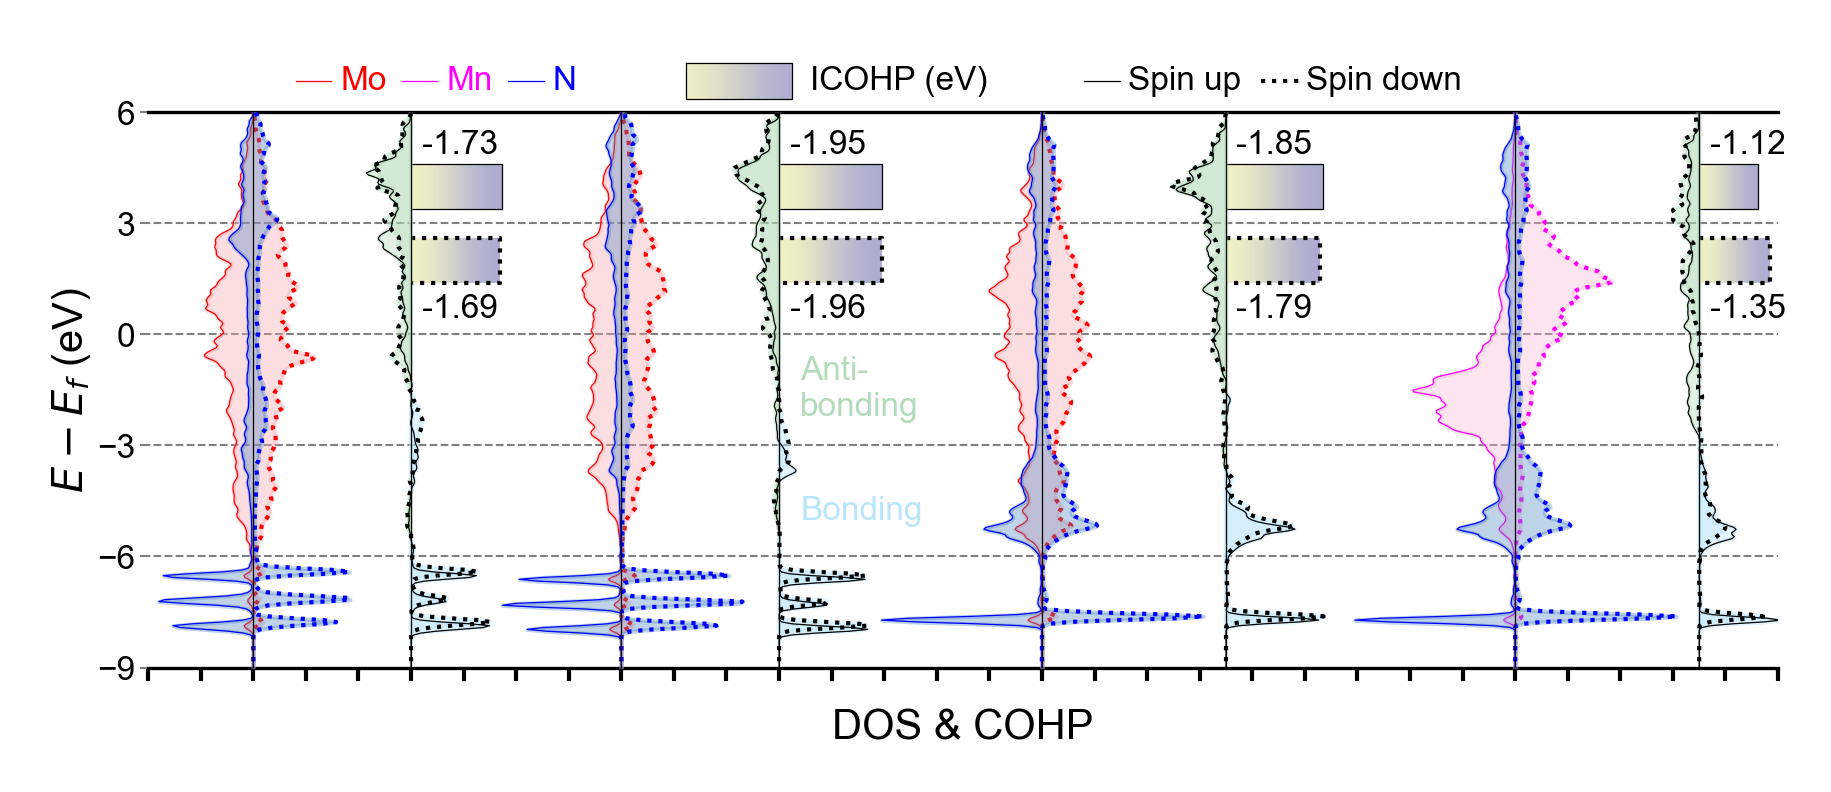

In [313]:
plt.rc('font',family='Arial')
l=15;h=6.2
fig=plt.figure(figsize=(l/2.54, h/2.54),dpi=300)

ax0=fig.add_axes([0,0,1,1])
ax0.set_xlim(0,1);ax0.set_ylim(0,1);ax0.set_xticks([]);ax0.set_yticks([]);ax0.axis('off')
ax0.patch.set_alpha(0.0)

ax=fig.add_axes([1./l, 0.8/h, 13.8/l, 4.7/h])
ax.tick_params(length=3,width=1,labelsize=8,pad=1, axis='x')
ax.tick_params(length=2,width=0.5,labelsize=8,pad=1, axis='y', color='grey')
ax.set_xlabel('DOS & COHP', fontsize=10, labelpad=6); ax.set_ylabel('$E-E_f$ (eV)', fontsize=10, labelpad=1)
ax.set_ylim(-9, 6); ax.set_yticks([-9, -6, -3, 0, 3, 6])
ax.set_xlim(0, 31)

# N2-Pd
## DOS
center = 2
ax.plot([center, center], [-10, 10], c='k', lw=0.3, zorder=16)
### N
data_up = LP_N2Pd.get_dos(36, 'p', Spin.up); data_down = LP_N2Pd.get_dos(36, 'p', Spin.down)
ax.plot(-1*data_up['dos'] + center, data_up['energies'], lw=0.3, c='b', zorder=10)
ax.plot(data_down['dos'] + center, data_down['energies'], lw=1.0, c='b', zorder=10, ls=':')
ax.fill_betweenx(data_up['energies'], -1*data_up['dos']+center, data_down['dos']+center, color='#5086C4', zorder=9, alpha=0.36)
### Mo
data_up = LP_N2Pd.get_dos(24, 'd', Spin.up); data_down = LP_N2Pd.get_dos(24, 'd', Spin.down)
ax.plot(-1*data_up['dos'] + center, data_up['energies'], lw=0.3, c='r', zorder=8)
ax.plot(data_down['dos'] + center, data_down['energies'], lw=1.0, c='r', zorder=8, ls=':')
ax.fill_betweenx(data_up['energies'], -1*data_up['dos']+center, data_down['dos']+center, color='#F7A6AC', zorder=7, alpha=0.36)
## COHP
center = 5
ax.plot([center, center], [-10, 10], c='k', lw=0.3, zorder=16)
### Spin up
cohp = LP_N2Pd.get_coxp(4); cohp_e = cohp['energies']
cohp_data = -1*np.array(cohp['COHP']['1']);cohp_anti=np.where(cohp_data<0, cohp_data, 0);cohp_bond=np.where(cohp_data>0, cohp_data, 0)
ax.fill_betweenx(cohp_e, cohp_anti+center, np.zeros(cohp_anti.shape)+center, color='#B2DBB9', where=cohp_anti<0, alpha=0.36)
ax.fill_betweenx(cohp_e, cohp_bond+center, np.zeros(cohp_bond.shape)+center, color='#B8E5FA', where=cohp_bond>0, alpha=0.36)
ax.plot(cohp_data + center, data_up['energies'], lw=0.3, c='k', zorder=10)
### Spin down
cohp_data = -1*np.array(cohp['COHP']['-1']);cohp_anti=np.where(cohp_data<0, cohp_data, 0);cohp_bond=np.where(cohp_data>0, cohp_data, 0)
ax.fill_betweenx(cohp_e, cohp_anti+center, np.zeros(cohp_anti.shape)+center, color='#B2DBB9', where=cohp_anti<0, zorder=9, alpha=0.36)
ax.fill_betweenx(cohp_e, cohp_bond+center, np.zeros(cohp_bond.shape)+center, color='#B8E5FA', where=cohp_bond>0, zorder=9, alpha=0.36)
ax.plot(cohp_data + center, data_up['energies'], lw=1.0, c='k', zorder=10, ls=':')
## ICOHP
x_I_up = [center, center+1.73, center+1.73, center]; y_I_up = [3.4, 3.4, 4.6, 4.6]
ax.plot(x_I_up, y_I_up, c='k', lw=0.3, zorder=6); ax.text(center+0.2, 4.7, '-1.73', fontsize=8, ha='left', va='bottom')
gradient_graphics(ax, x_I_up, y_I_up, colormap=[(0, '#EEF0A7'), (1, '#7C7CBA')], color_matrix=[(0, 1), (0, 1)], edge_para=['k', 0], zorder=5, alpha=0.66)
x_I_down = [center, center+1.69, center+1.69, center]; y_I_down = [2.6, 2.6, 1.4, 1.4]
ax.plot(x_I_down, y_I_down, c='k', lw=1.0, zorder=6, ls=':'); ax.text(center+0.2, 1.1, '-1.69', fontsize=8, ha='left', va='top')
gradient_graphics(ax, x_I_down, y_I_down, colormap=[(0, '#EEF0A7'), (1, '#7C7CBA')], color_matrix=[(0, 1), (0, 1)], edge_para=['k', 0], zorder=5, alpha=0.66)

# N2 Mo
## DOS
center = 9
ax.plot([center, center], [-10, 10], c='k', lw=0.3, zorder=16)
### N
data_up = LP_N2Mo.get_dos(36, 'p', Spin.up); data_down = LP_N2Mo.get_dos(36, 'p', Spin.down)
ax.plot(-1*data_up['dos'] + center, data_up['energies'], lw=0.3, c='b', zorder=10)
ax.plot(data_down['dos'] + center, data_down['energies'], lw=1.0, c='b', zorder=10, ls=':')
ax.fill_betweenx(data_up['energies'], -1*data_up['dos']+center, data_down['dos']+center, color='#5086C4', zorder=9, alpha=0.36)
### Mo
data_up = LP_N2Mo.get_dos(24, 'd', Spin.up); data_down = LP_N2Mo.get_dos(24, 'd', Spin.down)
ax.plot(-1*data_up['dos'] + center, data_up['energies'], lw=0.3, c='r', zorder=8)
ax.plot(data_down['dos'] + center, data_down['energies'], lw=1.0, c='r', zorder=8, ls=':')
ax.fill_betweenx(data_up['energies'], -1*data_up['dos']+center, data_down['dos']+center, color='#F7A6AC', zorder=7, alpha=0.36)
## COHP
center = 12
ax.plot([center, center], [-10, 10], c='k', lw=0.3, zorder=16)
### Spin up
cohp = LP_N2Mo.get_coxp(4); cohp_e = cohp['energies']
cohp_data = -1*np.array(cohp['COHP']['1']);cohp_anti=np.where(cohp_data<0, cohp_data, 0);cohp_bond=np.where(cohp_data>0, cohp_data, 0)
ax.fill_betweenx(cohp_e, cohp_anti+center, np.zeros(cohp_anti.shape)+center, color='#B2DBB9', where=cohp_anti<0, alpha=0.36)
ax.fill_betweenx(cohp_e, cohp_bond+center, np.zeros(cohp_bond.shape)+center, color='#B8E5FA', where=cohp_bond>0, alpha=0.36)
ax.plot(cohp_data + center, data_up['energies'], lw=0.3, c='k', zorder=10)
### Spin down
cohp_data = -1*np.array(cohp['COHP']['-1']);cohp_anti=np.where(cohp_data<0, cohp_data, 0);cohp_bond=np.where(cohp_data>0, cohp_data, 0)
ax.fill_betweenx(cohp_e, cohp_anti+center, np.zeros(cohp_anti.shape)+center, color='#B2DBB9', where=cohp_anti<0, zorder=9, alpha=0.36)
ax.fill_betweenx(cohp_e, cohp_bond+center, np.zeros(cohp_bond.shape)+center, color='#B8E5FA', where=cohp_bond>0, zorder=9, alpha=0.36)
ax.plot(cohp_data + center, data_up['energies'], lw=1.0, c='k', zorder=10, ls=':')
## ICOHP
x_I_up = [center, center+1.95, center+1.95, center]; y_I_up = [3.4, 3.4, 4.6, 4.6]
ax.plot(x_I_up, y_I_up, c='k', lw=0.3, zorder=6); ax.text(center+0.2, 4.7, '-1.95', fontsize=8, ha='left', va='bottom')
gradient_graphics(ax, x_I_up, y_I_up, colormap=[(0, '#EEF0A7'), (1, '#7C7CBA')], color_matrix=[(0, 1), (0, 1)], edge_para=['k', 0], zorder=5, alpha=0.66)
x_I_down = [center, center+1.96, center+1.96, center]; y_I_down = [2.6, 2.6, 1.4, 1.4]
ax.plot(x_I_down, y_I_down, c='k', lw=1.0, zorder=6, ls=':'); ax.text(center+0.2, 1.1, '-1.96', fontsize=8, ha='left', va='top')
gradient_graphics(ax, x_I_down, y_I_down, colormap=[(0, '#EEF0A7'), (1, '#7C7CBA')], color_matrix=[(0, 1), (0, 1)], edge_para=['k', 0], zorder=5, alpha=0.66)

# NH N-Mo
center = 17
ax.plot([center, center], [-10, 10], c='k', lw=0.3, zorder=16)
### N
data_up = LP_NH.get_dos(37, 'p', Spin.up); data_down = LP_NH.get_dos(37, 'p', Spin.down)
ax.plot(-1*data_up['dos'] + center, data_up['energies'], lw=0.3, c='b', zorder=10)
ax.plot(data_down['dos'] + center, data_down['energies'], lw=1.0, c='b', zorder=10, ls=':')
ax.fill_betweenx(data_up['energies'], -1*data_up['dos']+center, data_down['dos']+center, color='#5086C4', zorder=9, alpha=0.36)
### Mo
data_up = LP_NH.get_dos(24, 'd', Spin.up); data_down = LP_NH.get_dos(24, 'd', Spin.down)
ax.plot(-1*data_up['dos'] + center, data_up['energies'], lw=0.3, c='r', zorder=8)
ax.plot(data_down['dos'] + center, data_down['energies'], lw=1.0, c='r', zorder=8, ls=':')
ax.fill_betweenx(data_up['energies'], -1*data_up['dos']+center, data_down['dos']+center, color='#F7A6AC', zorder=7, alpha=0.36)
## COHP
center = 20.5
ax.plot([center, center], [-10, 10], c='k', lw=0.3, zorder=16)
### Spin up
cohp = LP_NH.get_coxp(3); cohp_e = cohp['energies']
cohp_data = -1*np.array(cohp['COHP']['1']);cohp_anti=np.where(cohp_data<0, cohp_data, 0);cohp_bond=np.where(cohp_data>0, cohp_data, 0)
ax.fill_betweenx(cohp_e, cohp_anti+center, np.zeros(cohp_anti.shape)+center, color='#B2DBB9', where=cohp_anti<0, alpha=0.36)
ax.fill_betweenx(cohp_e, cohp_bond+center, np.zeros(cohp_bond.shape)+center, color='#B8E5FA', where=cohp_bond>0, alpha=0.36)
ax.plot(cohp_data + center, data_up['energies'], lw=0.3, c='k', zorder=10)
### Spin down
cohp_data = -1*np.array(cohp['COHP']['-1']);cohp_anti=np.where(cohp_data<0, cohp_data, 0);cohp_bond=np.where(cohp_data>0, cohp_data, 0)
ax.fill_betweenx(cohp_e, cohp_anti+center, np.zeros(cohp_anti.shape)+center, color='#B2DBB9', where=cohp_anti<0, zorder=9, alpha=0.36)
ax.fill_betweenx(cohp_e, cohp_bond+center, np.zeros(cohp_bond.shape)+center, color='#B8E5FA', where=cohp_bond>0, zorder=9, alpha=0.36)
ax.plot(cohp_data + center, data_up['energies'], lw=1.0, c='k', zorder=10, ls=':')
## ICOHP
x_I_up = [center, center+1.85, center+1.85, center]; y_I_up = [3.4, 3.4, 4.6, 4.6]
ax.plot(x_I_up, y_I_up, c='k', lw=0.3, zorder=6); ax.text(center+0.2, 4.7, '-1.85', fontsize=8, ha='left', va='bottom')
gradient_graphics(ax, x_I_up, y_I_up, colormap=[(0, '#EEF0A7'), (1, '#7C7CBA')], color_matrix=[(0, 1), (0, 1)], edge_para=['k', 0], zorder=5, alpha=0.66)
x_I_down = [center, center+1.79, center+1.79, center]; y_I_down = [2.6, 2.6, 1.4, 1.4]
ax.plot(x_I_down, y_I_down, c='k', lw=1.0, zorder=6, ls=':'); ax.text(center+0.2, 1.1, '-1.79', fontsize=8, ha='left', va='top')
gradient_graphics(ax, x_I_down, y_I_down, colormap=[(0, '#EEF0A7'), (1, '#7C7CBA')], color_matrix=[(0, 1), (0, 1)], edge_para=['k', 0], zorder=5, alpha=0.66)

# NH N-Mn
center = 26
ax.plot([center, center], [-10, 10], c='k', lw=0.3, zorder=16)
### N
data_up = LP_NH.get_dos(37, 'p', Spin.up); data_down = LP_NH.get_dos(37, 'p', Spin.down)
ax.plot(-1*data_up['dos'] + center, data_up['energies'], lw=0.3, c='b', zorder=10)
ax.plot(data_down['dos'] + center, data_down['energies'], lw=1.0, c='b', zorder=10, ls=':')
ax.fill_betweenx(data_up['energies'], -1*data_up['dos']+center, data_down['dos']+center, color='#5086C4', zorder=9, alpha=0.36)
### Mn
data_up = LP_NH.get_dos(6, 'd', Spin.up); data_down = LP_NH.get_dos(6, 'd', Spin.down)
ax.plot(-1*data_up['dos'] + center, data_up['energies'], lw=0.3, c='fuchsia', zorder=8)
ax.plot(data_down['dos'] + center, data_down['energies'], lw=1.0, c='fuchsia', zorder=8, ls=':')
ax.fill_betweenx(data_up['energies'], -1*data_up['dos']+center, data_down['dos']+center, color='#F7B7D2', zorder=7, alpha=0.36)
## COHP
center = 29.5
ax.plot([center, center], [-10, 10], c='k', lw=0.3, zorder=16)
### Spin up
cohp = LP_NH.get_coxp(2); cohp_e = cohp['energies']
cohp_data = -1*np.array(cohp['COHP']['1']);cohp_anti=np.where(cohp_data<0, cohp_data, 0);cohp_bond=np.where(cohp_data>0, cohp_data, 0)
ax.fill_betweenx(cohp_e, cohp_anti+center, np.zeros(cohp_anti.shape)+center, color='#B2DBB9', where=cohp_anti<0, alpha=0.36)
ax.fill_betweenx(cohp_e, cohp_bond+center, np.zeros(cohp_bond.shape)+center, color='#B8E5FA', where=cohp_bond>0, alpha=0.36)
ax.plot(cohp_data + center, data_up['energies'], lw=0.3, c='k', zorder=10)
### Spin down
cohp_data = -1*np.array(cohp['COHP']['-1']);cohp_anti=np.where(cohp_data<0, cohp_data, 0);cohp_bond=np.where(cohp_data>0, cohp_data, 0)
ax.fill_betweenx(cohp_e, cohp_anti+center, np.zeros(cohp_anti.shape)+center, color='#B2DBB9', where=cohp_anti<0, zorder=9, alpha=0.36)
ax.fill_betweenx(cohp_e, cohp_bond+center, np.zeros(cohp_bond.shape)+center, color='#B8E5FA', where=cohp_bond>0, zorder=9, alpha=0.36)
ax.plot(cohp_data + center, data_up['energies'], lw=1.0, c='k', zorder=10, ls=':')
## ICOHP
x_I_up = [center, center+1.12, center+1.12, center]; y_I_up = [3.4, 3.4, 4.6, 4.6]
ax.plot(x_I_up, y_I_up, c='k', lw=0.3, zorder=6); ax.text(center+0.2, 4.7, '-1.12', fontsize=8, ha='left', va='bottom')
gradient_graphics(ax, x_I_up, y_I_up, colormap=[(0, '#EEF0A7'), (1, '#7C7CBA')], color_matrix=[(0, 1), (0, 1)], edge_para=['k', 0], zorder=5, alpha=0.66)
x_I_down = [center, center+1.35, center+1.35, center]; y_I_down = [2.6, 2.6, 1.4, 1.4]
ax.plot(x_I_down, y_I_down, c='k', lw=1.0, zorder=6, ls=':'); ax.text(center+0.2, 1.1, '-1.35', fontsize=8, ha='left', va='top')
gradient_graphics(ax, x_I_down, y_I_down, colormap=[(0, '#EEF0A7'), (1, '#7C7CBA')], color_matrix=[(0, 1), (0, 1)], edge_para=['k', 0], zorder=5, alpha=0.66)

# 
for y in [-6, -3, 0, 3, 6]:
    ax.plot([-10, 50], [y, y], lw=0.5, c='grey', ls='--', zorder=0)
ax.set_xticks([i for i in range(32)])
ax.set_xticklabels([])
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.text(12.4, -5, 'Bonding', fontsize=8, c='#B8E5FA'); ax.text(12.4, -2.2, 'Anti-\nbonding', fontsize=8, c='#B2DBB9')
ax0.plot([0.15,0.17], [0.93,0.93],c='r', lw=0.3); ax0.text(0.175, 0.93, 'Mo', fontsize=8, ha='left', va='center', c='r')
ax0.plot([0.21,0.23], [0.93,0.93],c='fuchsia', lw=0.3); ax0.text(0.235, 0.93, 'Mn', fontsize=8, ha='left', va='center', c='fuchsia')
ax0.plot([0.27,0.29], [0.93,0.93],c='b', lw=0.3); ax0.text(0.295, 0.93, 'N', fontsize=8, ha='left', va='center', c='b')
ax0.plot([0.37, 0.43, 0.43, 0.37, 0.37], [0.955, 0.955, 0.905, 0.905, 0.955], lw=0.3, c='k', zorder=6)
gradient_graphics(ax0, [0.37, 0.43, 0.43, 0.37], [0.955, 0.955, 0.905, 0.905], colormap=[(0, '#EEF0A7'), (1, '#7C7CBA')], color_matrix=[(0, 1), (0, 1)], extend=0.01, edge_para=['k', 0], zorder=5, alpha=0.66)
ax0.text(0.44, 0.93, 'ICOHP (eV)', fontsize=8, ha='left', va='center')
ax0.plot([0.595,0.615], [0.93,0.93],c='k', lw=0.3); ax0.text(0.62, 0.93, 'Spin up', fontsize=8, ha='left', va='center', c='k')
ax0.plot([0.695,0.717], [0.93,0.93],c='k', lw=1.0, ls=':'); ax0.text(0.72, 0.93, 'Spin down', fontsize=8, ha='left', va='center', c='k')

# fig.savefig('Figure_6_f.tif',dpi=300)